# Raw result analysis (original dataset from the paper)

In [1]:
!pwd

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
from analysis import load_experiment_data, plot_general_accuracy, plot_intervention_success_rate, calculate_clique_sizes


/home/vic/files/GenMod/Interchange/analysis/result_analysis


In [2]:
RESULTS_DIR = "../results_mqnli/mqnli"

df = load_experiment_data(RESULTS_DIR)

# look at the (unique) abstract variables and layers we loaded
print("High nodes (abstract variables):", df['high_node'].unique())
print("Low nodes (neural layers):", df['low_node'].unique())

Loaded 9680000 total intervention experiments.
High nodes (abstract variables): <StringArray>
[       'obj',    'obj_adj',      'v_adv',        'neg',     'v_verb',
       'subj',       'negp',      'v_bar',         'vp',  'subj_noun',
   'subj_adj',       'vp_q',   'obj_noun', 'sentence_q']
Length: 14, dtype: str
Low nodes (neural layers): <StringArray>
[ 'bert_layer_5', 'bert_layer_10',  'bert_layer_9',  'bert_layer_4',
  'bert_layer_1',  'bert_layer_6',  'bert_layer_3',  'bert_layer_2',
  'bert_layer_7',  'bert_layer_0',  'bert_layer_8']
Length: 11, dtype: str


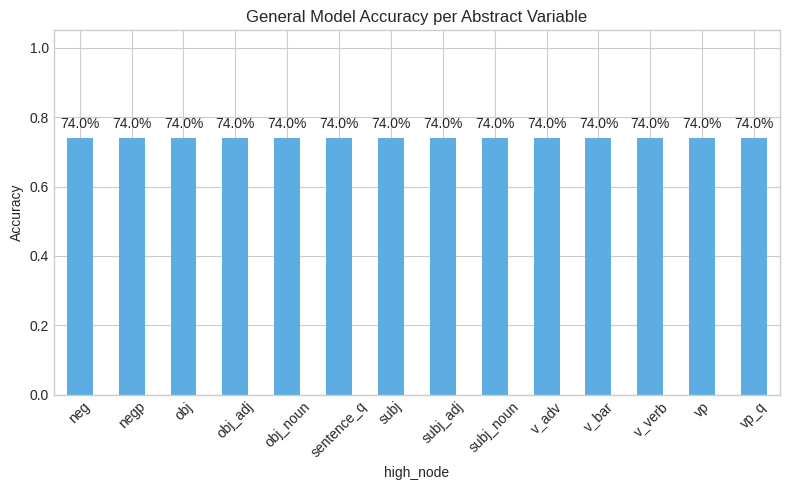

In [3]:
plot_general_accuracy(df, "mqnli")

The 80.5% reported in the paper is their overall test accuracy on the entire MQNLI dataset from what I understand. The 74% here is the accuracy calculated strictly on the subset of examples we selected for the interchange experiments; our test set. 

We still have a model that has learned the task reasonably well (way above random guessing), so our subsequent intervention plots will still yield meaningful insights about the model's causal structure.

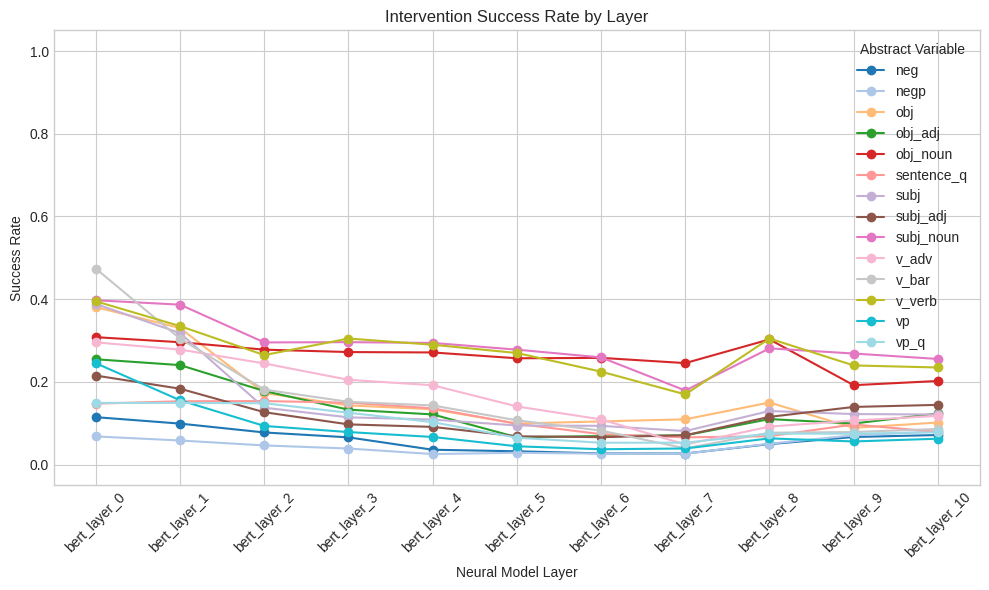

In [4]:

plot_intervention_success_rate(df, "mqnli")

this is essentially a map of "where the model is doing its thinking" for different parts of a sentence.

so here we take two sentences, pick a specific layer in BERT, and swap (intervene on) the neural representation of a specific variable (like the subject, subj).

Success Rate: When we swap this neural representation, does the model's final prediction change exactly the way the natural logic causal model predicts it should?

v_bar peaks at the very beginning, and subject_noun (along with v_verb and obj_noun) remains high and stable at the later layers. 


The intervention success rates reveals a present division of labor inside the model, defined by a syntax first and logic later. Basic grammatical structures are heavily localized at the very beginning with variables like v_bar, subj, and obj peaking between 38% and 47% in Layer 0 before rapidly diffusing and dropping to around 10% by Layer 10. Conversely, logical operators such as negp follow an inverted path, starting low in the early layers and becoming slightly more structurally defined at the end of the network as the model synthesizes meaning. While these raw success rates might seem surprisingly low across the board, as the paper states, this is just an artifact of averaging over the inherently noisy dataset; because a single variable rarely occupies the exact same neuron for every single sentence, calculating "Clique Size" becomes necessary to isolate the specific data subgroups where intervention success is effectively 100%.

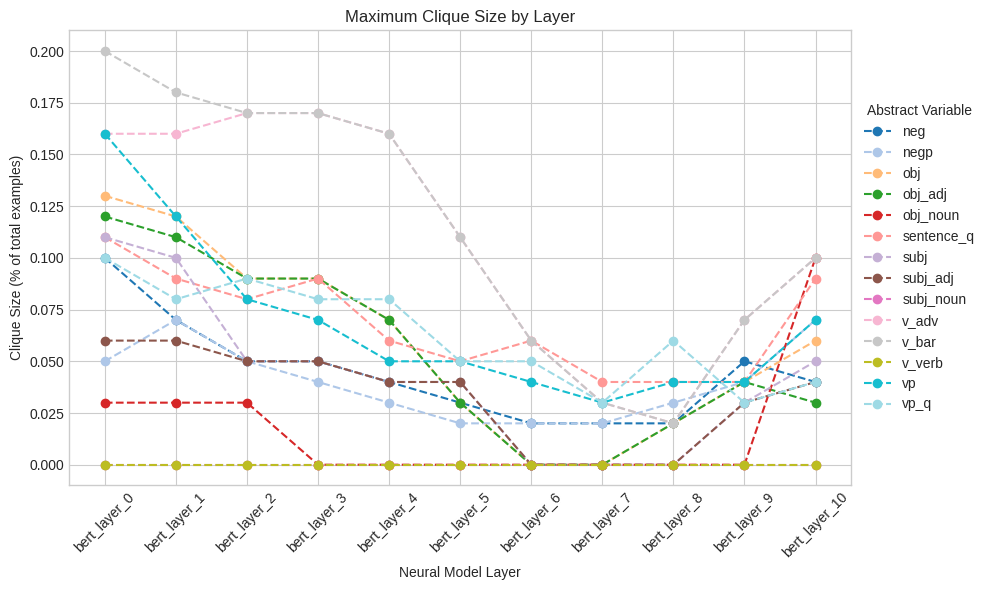

In [6]:
import numpy as np

def plot_clique_sizes(df):
    clique_df = calculate_clique_sizes(df)
    
    clique_pivot = clique_df.pivot(index='high_node', columns='low_node', values='clique_percentage')
    
    # sort columns
    sorted_columns = sorted(clique_pivot.columns, key=lambda x: int(x.split('_')[-1]))
    clique_pivot = clique_pivot[sorted_columns]
    clique_pivot.to_csv('clique_sizes_pivoted_mqnli.csv')
    
    fig, ax = plt.subplots(figsize=(10, 6))
    

    colors = plt.cm.tab20(np.linspace(0, 1, len(clique_pivot.index)))
    
    for i, high_node in enumerate(clique_pivot.index):
        ax.plot(clique_pivot.columns, clique_pivot.loc[high_node], marker='o', linestyle='--', label=high_node, color=colors[i])
        
    ax.set_title("Maximum Clique Size by Layer")
    ax.set_ylabel("Clique Size (% of total examples)")
    ax.set_xlabel("Neural Model Layer")
    # change location to outside of plot
    ax.legend(title="Abstract Variable", loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_clique_sizes(df)

When we look closely at this clique size data, our reproduction reveals that the BERT model did not fully learn the causal logic of the dataset.

When evaluating structural alignment using an exact graph search (provided by NetworkX library), we saw that variables like v_verb and subj_noun had massive clique sizes (around 73% to 74%). The model perfectly encoded the surface-level lexical items. However, when applying the paper's strict heuristic algorithm which requires these variables to actively cause a change in the model's final prediction; the clique sizes for these lexical variables plummeted to near 0%. This indicates that while the model tracks these words, it does not rely on them compositionally to solve the task.

The original authors explicitly highlight an effect: lexical/syntactic variables align with the lower layers of BERT, while logical variables (specifically negation) align with the later layers. In their findings, proving that BERT systematically encoded the logical structure of the sentence (e.g., reaching a 38.3% clique size for NPObj) was a major scientific breakthrough against baselines that memorized statistical noise.

Our reproduction failed to replicate this deep logical observation. In our case, negp starts at 5% and only barely crawls up to 7% by layer 10, while neg actually drops from 10% to 4%. A major explanation for this failure to generalize is our base accuracy of 74%. Our model likely hit a local minimum where it memorized enough shallow syntactic patterns to achieve a decent score, but it failed to cross the threshold into true compositional reasoning